In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 80.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=2352c617455557e914c60d453586a4b29bb17b2d6c66e541c4c19725ce579d73
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


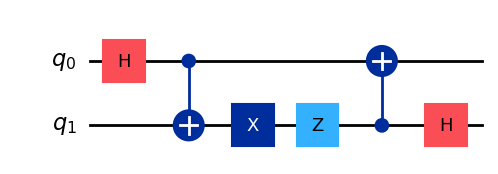

In [2]:
# Superdense coding

# The classical 2-bit value is encoded by applying X and/or Z gates

sdc = QuantumCircuit(2)

# qubits 0 and 1 are the shared entangled state
# Alice has qubit 1, Bob has qubit 0

# Entangle qubits 0 and 1
sdc.h(0)
sdc.cx(0,1)

# Encoding by Alice, working on qubit 1
# For each of 00, 01, 10, 11, there is a block of code that can be commented or uncommented.

# For 00, do nothing

# For 01, apply X to qubit 1
#sdc.x(1)

# For 10, apply Z to qubit 1
#sdc.z(1)

# For 11, apply X then Z to qubit 1
sdc.x(1)
sdc.z(1)

# Decoding by Bob, working on qubits 0 and 1

sdc.cx(1,0)
sdc.h(1)

sdc.draw("mpl")

In [3]:
state = Statevector.from_int(0, 4)  # 4 basis states on 2 qubits

# Apply the circuit to the state
state = state.evolve(sdc)

# Display using latex.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

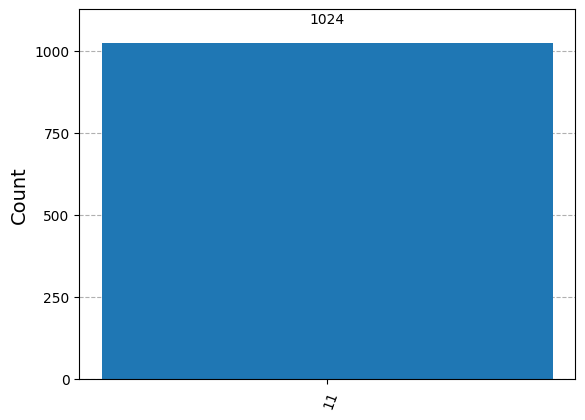

In [4]:
# EXERCISE

# Instead of calculating the state and displaying it, try simulating the circuit
# in a similar way to previous exercises. You will need to add some measurements
# so that you can check that the measurement statistics match the value that Alice
# encoded.

# SOLUTION:
# We rebuild sdc with 2 classical bits so we can measure both qubits.
# After decoding, qubit 1 gives bit 1 (b1) and qubit 0 gives bit 0 (b0).
# For encoding 11 (X then Z): we expect both measurement bits to be 1.

sdc_sim = QuantumCircuit(2, 2)

# Entangle qubits 0 and 1
sdc_sim.h(0)
sdc_sim.cx(0, 1)

# Encoding by Alice, working on qubit 1
# For 00, do nothing

# For 01, apply X to qubit 1
#sdc_sim.x(1)

# For 10, apply Z to qubit 1
#sdc_sim.z(1)

# For 11, apply X then Z to qubit 1
sdc_sim.x(1)
sdc_sim.z(1)

# Decoding by Bob, working on qubits 0 and 1
sdc_sim.cx(1, 0)
sdc_sim.h(1)

# Measure both qubits: qubit 1 -> classical bit 1, qubit 0 -> classical bit 0
sdc_sim.measure([0, 1], [0, 1])

# Simulate using BasicSimulator (no noise needed for superdense coding
# since we do not use if_test / control flow)
backend = BasicSimulator()
compiled = transpile(sdc_sim, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)

# For encoding 11 we expect all shots to land on "11" (both bits 1)
plot_histogram(counts)

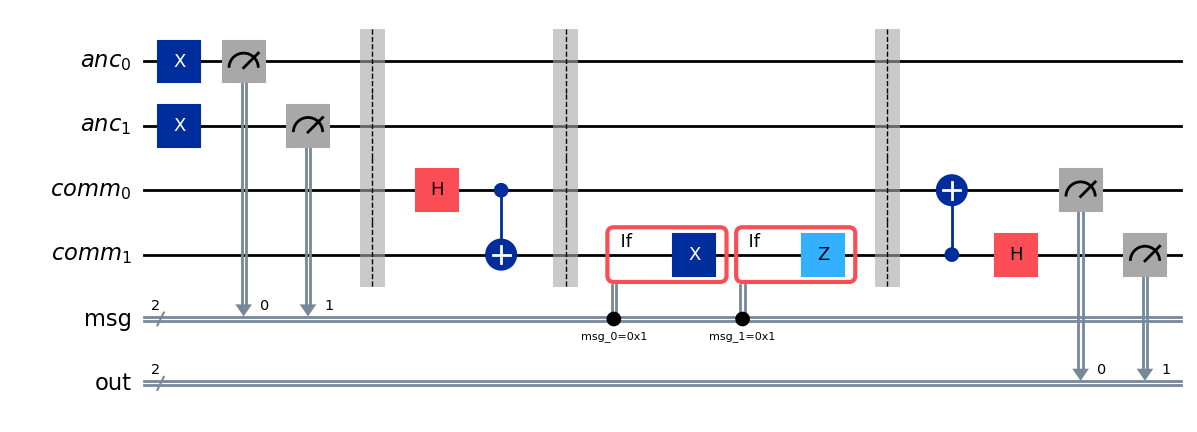

In [5]:
# EXERCISE

# A better implementation of superdense coding uses two classical bits as inputs,
# and the conditional operators that we saw in Lab-2B. Encoding the two-bit
# classical value is similar to the last stage of teleportation, where the measurement
# results are used to adjust Bob's qubit.

# Implement superdense coding this way.

# SOLUTION:
# We use 2 qubits and 4 classical bits:
#   classical bits 0 and 1: the INPUT message Alice wants to send (b0, b1)
#   classical bits 2 and 3: the OUTPUT measurement results Bob reads
#
# We pre-set the classical input bits using a trick:
# initialise the circuit, then manually force the classical register
# by prepending an X gate on an ancilla qubit and measuring it.
#
# A cleaner way in Qiskit is to use the initialize() instruction or
# to use classical_function / classical registers directly.
#
# Here we use the same if_test pattern as in Lab-2B teleportation,
# where classical bit values drive which gates are applied.

# We build a 2-qubit, 4-classical-bit circuit.
# Classical bits 0,1 hold Alice's input message.
# We initialise them to the message we want (here: 1,1 for message "11")
# by measuring two ancilla qubits prepared in |1> states.

from qiskit import ClassicalRegister, QuantumRegister

# Define registers explicitly for clarity
msg  = ClassicalRegister(2, name='msg')   # Alice's 2-bit input message
out  = ClassicalRegister(2, name='out')   # Bob's decoded output
anc  = QuantumRegister(2, name='anc')     # ancilla qubits to set the classical message
comm = QuantumRegister(2, name='comm')    # communication qubits (shared Bell pair)

sdc_cond = QuantumCircuit(anc, comm, msg, out)

# ---- Set Alice's message bits using ancilla qubits ----
# To send message "11": flip both ancilla qubits to |1>, then measure into msg
# To send "01": flip only anc[0]; to send "10": flip only anc[1]; to send "00": flip neither.
sdc_cond.x(anc[0])  # set msg bit 0 = 1
sdc_cond.x(anc[1])  # set msg bit 1 = 1
sdc_cond.measure(anc[0], msg[0])
sdc_cond.measure(anc[1], msg[1])

sdc_cond.barrier()

# ---- Entangle the communication qubits (shared Bell pair) ----
# comm[0] belongs to Bob, comm[1] belongs to Alice
sdc_cond.h(comm[0])
sdc_cond.cx(comm[0], comm[1])

sdc_cond.barrier()

# ---- Alice encodes her message onto comm[1] using if_test ----
# msg[0] = 1 -> apply X to comm[1]
with sdc_cond.if_test((msg[0], 1)):
    sdc_cond.x(comm[1])
# msg[1] = 1 -> apply Z to comm[1]
with sdc_cond.if_test((msg[1], 1)):
    sdc_cond.z(comm[1])

# Alice sends comm[1] to Bob (represented by the wire continuing to Bob's decode step)

sdc_cond.barrier()

# ---- Bob decodes: CNOT then H, then measure both qubits ----
sdc_cond.cx(comm[1], comm[0])
sdc_cond.h(comm[1])
sdc_cond.measure(comm[0], out[0])
sdc_cond.measure(comm[1], out[1])

sdc_cond.draw("mpl")

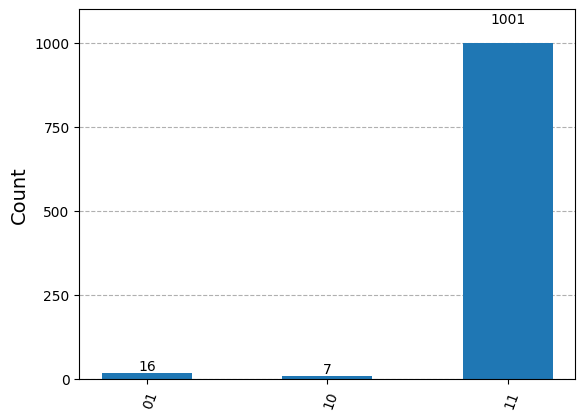

In [6]:
# Simulate the conditional superdense coding circuit.
# We use GenericBackendV2 with control_flow=True because if_test requires it.
# The output register (out) should match the message register (msg) in all shots.

backend = GenericBackendV2(num_qubits=4, control_flow=True)
compiled = transpile(sdc_cond, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)

# Marginalise to only the output bits to check Bob decoded correctly
# out[1] out[0] should match msg[1] msg[0]
mcounts = marginal_counts(counts, indices=[2, 3])  # out register is bits 2,3
plot_histogram(mcounts)